In [3]:
import pandas as pd

In [4]:
df=pd.read_excel('Anemia Dataset.xlsx')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          1000 non-null   object 
 1   Age             1000 non-null   int64  
 2   Hb              1000 non-null   float64
 3   RBC             1000 non-null   float64
 4   PCV             1000 non-null   float64
 5   MCV             1000 non-null   float64
 6   MCH             1000 non-null   float64
 7   MCHC            1000 non-null   float64
 8   Decision_Class  1000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])



In [7]:
import numpy as np


df_cleaned = df.copy()

# Select numeric columns
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_value = df_cleaned[col].median()

    # Detect outliers
    outliers = (df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)

    # Median capping
    df_cleaned.loc[outliers, col] = median_value

    print(f"{col}: {outliers.sum()} outliers capped")

print("DataFrame after IQR-based median capping:")
print(df_cleaned)


Gender: 0 outliers capped
Age: 4 outliers capped
Hb: 51 outliers capped
RBC: 36 outliers capped
PCV: 28 outliers capped
MCV: 38 outliers capped
MCH: 29 outliers capped
MCHC: 60 outliers capped
Decision_Class: 0 outliers capped
DataFrame after IQR-based median capping:
     Gender  Age    Hb   RBC   PCV   MCV   MCH  MCHC  Decision_Class
0         0   32  10.9  4.26  34.2  80.2  25.5  35.7               1
1         0   45   9.6  3.64  29.9  82.1  26.4  35.7               1
2         0   38  10.1  3.70  32.4  87.6  27.4  35.7               1
3         1   37  11.0  3.93  33.6  85.3  27.9  35.7               1
4         0   50  12.1  4.16  36.5  87.9  29.2  33.2               0
..      ...  ...   ...   ...   ...   ...   ...   ...             ...
995       0   32  10.4  4.49  28.4  63.2  21.2  33.5               1
996       1   48  13.7  4.37  37.8  86.6  31.4  36.2               0
997       1   19  12.1  4.17  33.5  80.4  28.9  36.0               0
998       0   35  12.2  4.28  33.5  78.4 

In [9]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


X = df_cleaned.drop(columns=['Decision_Class'])
y = df_cleaned['Decision_Class']


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply Chi-square test
chi2_values, p_values = chi2(X_scaled, y)

# Create DataFrame of results
chi2_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi2_values,
    'p-value': p_values
})

# Identify insignificant features
insignificant_features = chi2_df[chi2_df['p-value'] > 0.05]


df_cleaned = df_cleaned.drop(columns=insignificant_features['Feature'])

print("Insignificant Features (Chi-Square Test):")
print(insignificant_features)


Insignificant Features (Chi-Square Test):
  Feature  Chi2 Score   p-value
1     Age    0.480651  0.488127
7    MCHC    2.945974  0.086092


In [10]:

df_cleaned


,Gender,Hb,RBC,PCV,MCV,MCH,Decision_Class
0,0,10.9,4.26,34.2,80.2,25.5,1
1,0,9.6,3.64,29.9,82.1,26.4,1
2,0,10.1,3.70,32.4,87.6,27.4,1
3,1,11.0,3.93,33.6,85.3,27.9,1
4,0,12.1,4.16,36.5,87.9,29.2,0
...,...,...,...,...,...,...,...
995,0,10.4,4.49,28.4,63.2,21.2,1
996,1,13.7,4.37,37.8,86.6,31.4,0
997,1,12.1,4.17,33.5,80.4,28.9,0
998,0,12.2,4.28,33.5,78.4,28.6,0


In [11]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.2 MB/s eta 0:00:00


Generation 1: Best Accuracy = 0.9940
Generation 2: Best Accuracy = 0.9940
Generation 3: Best Accuracy = 0.9940
Generation 4: Best Accuracy = 0.9940
Generation 5: Best Accuracy = 0.9940
Generation 6: Best Accuracy = 0.9940
Generation 7: Best Accuracy = 0.9940
Generation 8: Best Accuracy = 0.9940
Generation 9: Best Accuracy = 0.9940
Generation 10: Best Accuracy = 0.9940
Generation 11: Best Accuracy = 0.9940
Generation 12: Best Accuracy = 0.9940
Generation 13: Best Accuracy = 0.9940
Generation 14: Best Accuracy = 0.9940
Generation 15: Best Accuracy = 0.9940
Generation 16: Best Accuracy = 0.9940
Generation 17: Best Accuracy = 0.9940
Generation 18: Best Accuracy = 0.9940
Generation 19: Best Accuracy = 0.9940
Generation 20: Best Accuracy = 0.9940
Generation 21: Best Accuracy = 0.9940
Generation 22: Best Accuracy = 0.9940
Generation 23: Best Accuracy = 0.9940
Generation 24: Best Accuracy = 0.9940
Generation 25: Best Accuracy = 0.9940
Generation 26: Best Accuracy = 0.9940
Generation 27: Best A

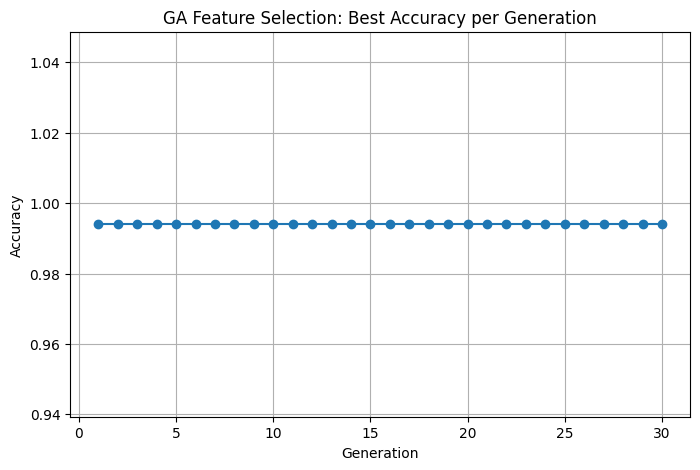

In [12]:



import random
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

# =========================
# Prepare data
# =========================
X = df_cleaned.drop(columns=['Decision_Class']).values
y = df_cleaned['Decision_Class'].values
n_features = X.shape[1]


# Maximize accuracy
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()


toolbox.register("attr_bool", random.randint, 0, 1)

# Structure initializers
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


def evalFitness(individual):
    if sum(individual) == 0:
        return 0.,
    selected_features = [i for i, bit in enumerate(individual) if bit == 1]
    X_selected = X[:, selected_features]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(clf, X_selected, y, cv=5, scoring='accuracy')
    return scores.mean(),

toolbox.register("evaluate", evalFitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# =========================
# Run GA
# =========================
population = toolbox.population(n=20)
ngen = 30
cxpb = 0.5
mutpb = 0.2

fitness_history = []

for gen in range(ngen):
    offspring = algorithms.varAnd(population, toolbox, cxpb, mutpb)
    fits = list(map(toolbox.evaluate, offspring))
    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit
    population = toolbox.select(offspring, k=len(population))

    top_fit = max([ind.fitness.values[0] for ind in population])
    fitness_history.append(top_fit)
    print(f"Generation {gen+1}: Best Accuracy = {top_fit:.4f}")

# =========================
# Get best individual
# =========================
best_ind = tools.selBest(population, k=1)[0]
selected_features = [i for i, bit in enumerate(best_ind) if bit == 1]
print("Selected feature indices:", selected_features)
print("Selected feature names:", df_cleaned.drop(columns=['Decision_Class']).columns[selected_features].tolist())

# =========================
# Plot fitness over generations
# =========================
plt.figure(figsize=(8,5))
plt.plot(range(1, ngen+1), fitness_history, marker='o')
plt.title("GA Feature Selection: Best Accuracy per Generation")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


Feature importance (data-driven, model-free):
  Feature  MI_Importance
1      Hb       0.595077
3     PCV       0.327771
2     RBC       0.116185
5     MCH       0.069046
0  Gender       0.053803
4     MCV       0.050803


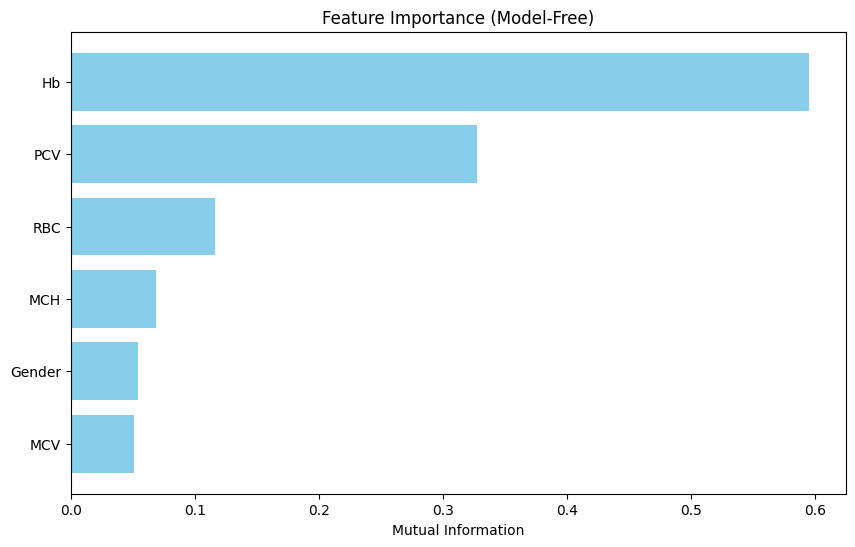

In [13]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

X = df_cleaned.drop('Decision_Class', axis=1)
y = df_cleaned['Decision_Class']


mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Importance': mi
}).sort_values(by='MI_Importance', ascending=False)

print("Feature importance (data-driven, model-free):")
print(importance_df)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['MI_Importance'], color='skyblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel("Mutual Information")
plt.title("Feature Importance (Model-Free)")
plt.show()


In [14]:
df_cleaned = df_cleaned[['Hb', 'PCV', 'Decision_Class']]

print("Updated df_cleaned with only selected features:")
print(df_cleaned.head())

Updated df_cleaned with only selected features:
     Hb   PCV  Decision_Class
0  10.9  34.2               1
1   9.6  29.9               1
2  10.1  32.4               1
3  11.0  33.6               1
4  12.1  36.5               0


In [32]:
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(df_cleaned, test_size=0.25, random_state=42)

In [33]:
train_df['Decision_Class'].value_counts()


,count
Decision_Class,
1,482
0,268


In [34]:
from imblearn.combine import SMOTETomek
from collections import Counter
import pandas as pd


X = train_df.drop(columns=['Decision_Class'])
y = train_df['Decision_Class']


smote_tomek = SMOTETomek(sampling_strategy={0: 600, 1: 600}, random_state=42)


X_res, y_res = smote_tomek.fit_resample(X, y)


print("Class distribution after SMOTETomek:", Counter(y_res))


train_df_balanced = pd.DataFrame(X_res, columns=X.columns)
train_df_balanced['Decision_Class'] = y_res

# Display the balanced DataFrame
print(train_df_balanced.head())


Class distribution after SMOTETomek: Counter({0: 597, 1: 597})
     Hb   PCV  Decision_Class
0  12.1  34.5               0
1  10.2  30.6               1
2  11.6  37.4               1
3  12.0  36.0               0
4   9.8  24.5               1


In [20]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Prepare data
X_train = train_df_balanced.drop(columns=['Decision_Class'])
y_train = train_df_balanced['Decision_Class']


classifiers = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Extra Trees": {
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 5, 10]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "CatBoost": {
        "model": CatBoostClassifier(verbose=0, random_state=42),
        "params": {
            "iterations": [100, 200],
            "depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    }
}


for name, clf_info in classifiers.items():
    grid = GridSearchCV(clf_info["model"], clf_info["params"], cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"{name} best parameters: {grid.best_params_}")


Decision Tree best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Extra Trees best parameters: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:47:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
CatBoost best parameters: {'depth': 7, 'iterations': 200, 'learning_rate': 0.1}


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.3 MB/s eta 0:00:00


In [36]:
import time
import psutil
import os
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd

# Features and target
X_train = train_df_balanced.drop(columns=['Decision_Class'])
y_train = train_df_balanced['Decision_Class']


models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(criterion='gini', max_depth=None, n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(depth=7, iterations=200, learning_rate=0.1, random_state=42, verbose=0)
}

# Function to check memory usage
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)  # in MB

# Train models and print detailed reports
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    mem_before = get_memory_usage()
    start_time = time.time()

    model.fit(X_train, y_train)

    end_time = time.time()
    mem_after = get_memory_usage()

    # Predictions on training set
    y_pred = model.predict(X_train)

    # Classification report
    report = classification_report(y_train, y_pred, digits=4)

    print(f"Classification Report for {name}:\n{report}")
    print(f"Training time: {end_time - start_time:.4f} seconds")
    print(f"Memory usage increase: {mem_after - mem_before:.2f} MB")



--- Training Decision Tree ---
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0     0.9983    0.9933    0.9958       597
           1     0.9933    0.9983    0.9958       597

    accuracy                         0.9958      1194
   macro avg     0.9958    0.9958    0.9958      1194
weighted avg     0.9958    0.9958    0.9958      1194

Training time: 0.0132 seconds
Memory usage increase: 0.00 MB

--- Training Extra Trees ---
Classification Report for Extra Trees:
              precision    recall  f1-score   support

           0     0.9983    0.9933    0.9958       597
           1     0.9933    0.9983    0.9958       597

    accuracy                         0.9958      1194
   macro avg     0.9958    0.9958    0.9958      1194
weighted avg     0.9958    0.9958    0.9958      1194

Training time: 0.3029 seconds
Memory usage increase: 0.00 MB

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:49:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report for XGBoost:
              precision    recall  f1-score   support

           0     0.9950    0.9933    0.9941       597
           1     0.9933    0.9950    0.9941       597

    accuracy                         0.9941      1194
   macro avg     0.9941    0.9941    0.9941      1194
weighted avg     0.9941    0.9941    0.9941      1194

Training time: 0.3742 seconds
Memory usage increase: 0.00 MB

--- Training CatBoost ---
Classification Report for CatBoost:
              precision    recall  f1-score   support

           0     0.9966    0.9933    0.9950       597
           1     0.9933    0.9966    0.9950       597

    accuracy                         0.9950      1194
   macro avg     0.9950    0.9950    0.9950      1194
weighted avg     0.9950    0.9950    0.9950      1194

Training time: 1.3253 seconds
Memory usage increase: 2.12 MB



--- Evaluating Decision Tree ---
Classification Report:
               precision    recall  f1-score   support

           0     0.9891    1.0000    0.9945        91
           1     1.0000    0.9937    0.9968       159

    accuracy                         0.9960       250
   macro avg     0.9946    0.9969    0.9957       250
weighted avg     0.9960    0.9960    0.9960       250

Accuracy: 0.9960 (95% CI: 0.9882 - 1.0038)
Matthews Correlation Coefficient (MCC): 0.9914
McNemar's test p-value: 1.0000


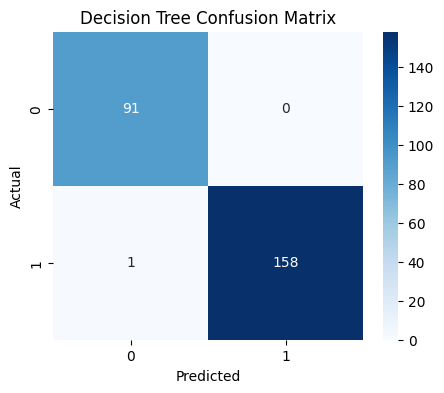

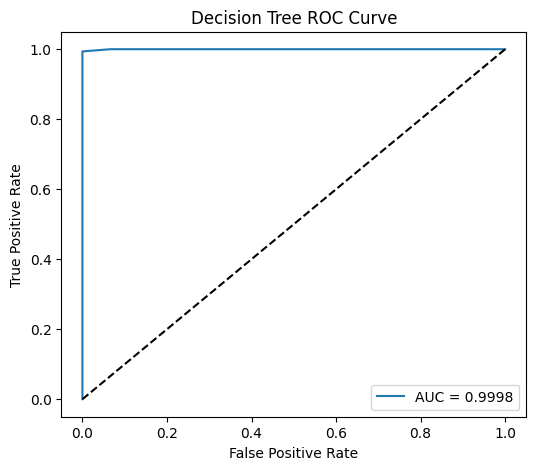

AUC: 0.9998


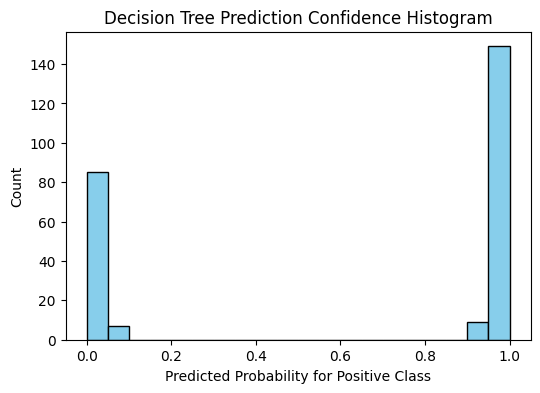

Inference time: 0.0051 seconds
Memory usage increase: 0.00 MB

--- Evaluating Extra Trees ---
Classification Report:
               precision    recall  f1-score   support

           0     0.9674    0.9780    0.9727        91
           1     0.9873    0.9811    0.9842       159

    accuracy                         0.9800       250
   macro avg     0.9774    0.9796    0.9785       250
weighted avg     0.9801    0.9800    0.9800       250

Accuracy: 0.9800 (95% CI: 0.9626 - 0.9974)
Matthews Correlation Coefficient (MCC): 0.9569
McNemar's test p-value: 1.0000


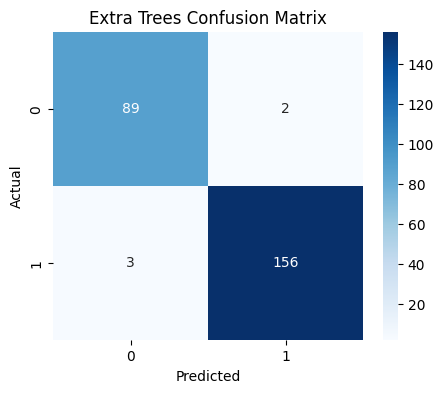

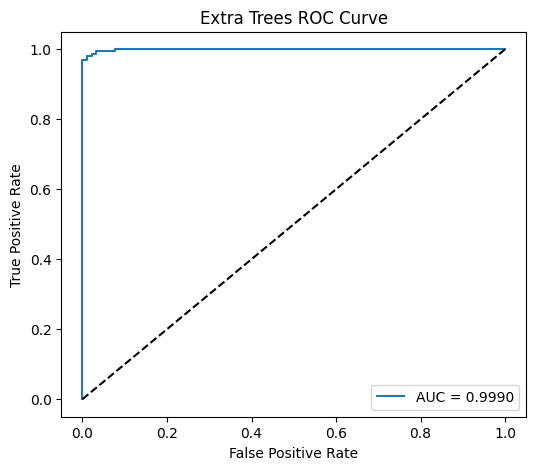

AUC: 0.9990


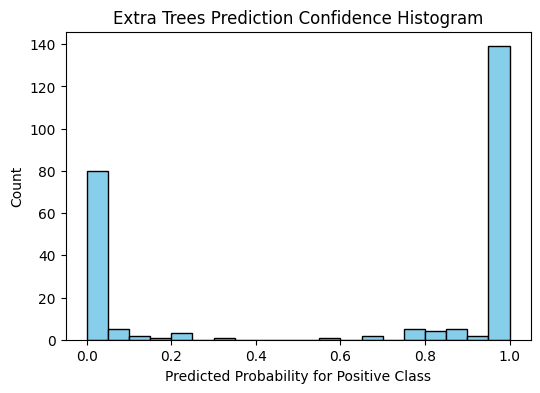

Inference time: 0.0915 seconds
Memory usage increase: 0.00 MB

--- Evaluating XGBoost ---
Classification Report:
               precision    recall  f1-score   support

           0     0.9891    1.0000    0.9945        91
           1     1.0000    0.9937    0.9968       159

    accuracy                         0.9960       250
   macro avg     0.9946    0.9969    0.9957       250
weighted avg     0.9960    0.9960    0.9960       250

Accuracy: 0.9960 (95% CI: 0.9882 - 1.0038)
Matthews Correlation Coefficient (MCC): 0.9914
McNemar's test p-value: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:49:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


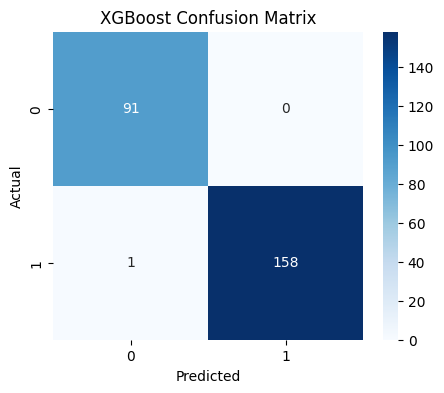

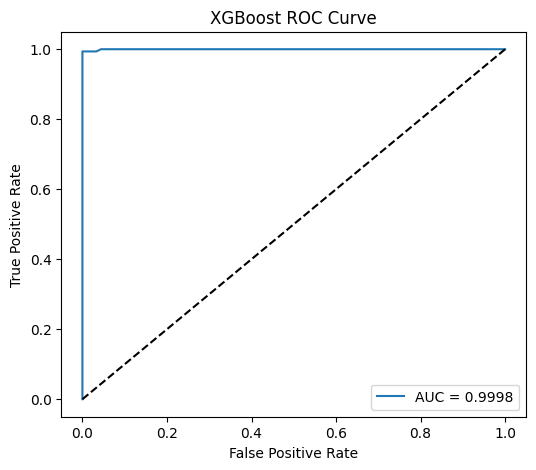

AUC: 0.9998


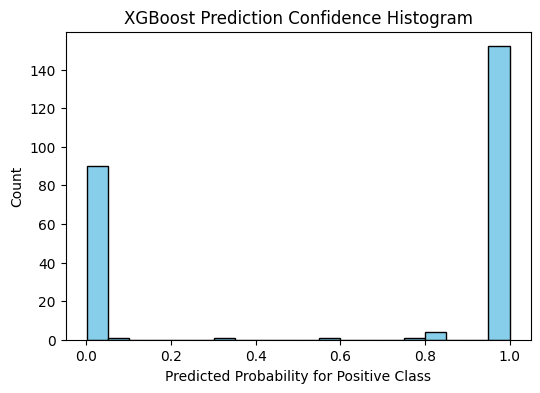

Inference time: 0.0652 seconds
Memory usage increase: 0.00 MB

--- Evaluating CatBoost ---
Classification Report:
               precision    recall  f1-score   support

           0     0.9785    1.0000    0.9891        91
           1     1.0000    0.9874    0.9937       159

    accuracy                         0.9920       250
   macro avg     0.9892    0.9937    0.9914       250
weighted avg     0.9922    0.9920    0.9920       250

Accuracy: 0.9920 (95% CI: 0.9810 - 1.0030)
Matthews Correlation Coefficient (MCC): 0.9829
McNemar's test p-value: 0.5000


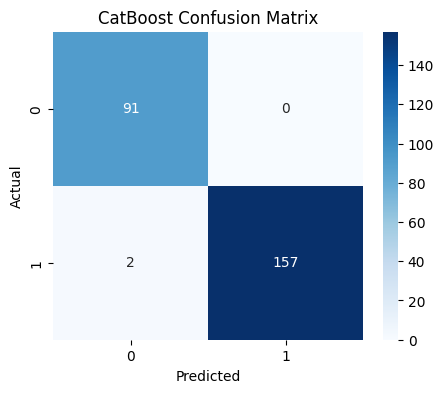

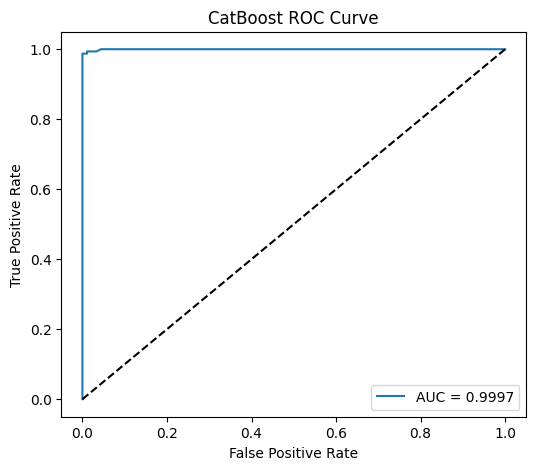

AUC: 0.9997


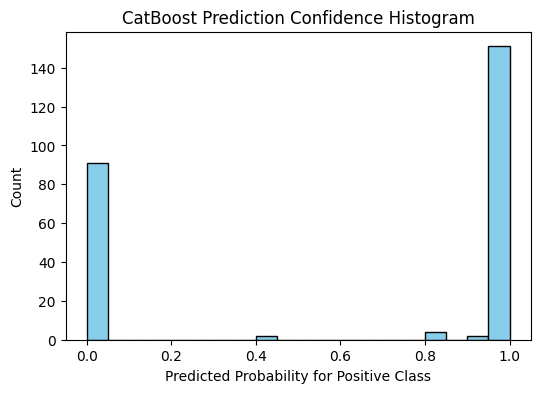

Inference time: 0.1853 seconds
Memory usage increase: -1.18 MB


In [37]:
import time
import psutil
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef,
    accuracy_score
)
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Features and target from test set
X_test = test_df.drop(columns=['Decision_Class'])
y_test = test_df['Decision_Class']

# Define tuned models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(criterion='gini', max_depth=None, n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(max_depth=5, n_estimators=200, learning_rate=0.2, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(depth=3, iterations=200, learning_rate=0.1, verbose=0, random_state=42)
}

# Function to check memory usage
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)  # in MB

# Evaluate each model
for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")

    mem_before = get_memory_usage()
    start_time = time.time()

    # Train on full training data
    model.fit(X_train, y_train)

    # Predictions on test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    end_time = time.time()
    mem_after = get_memory_usage()
    inference_time = end_time - start_time

    # Classification report
    report = classification_report(y_test, y_pred, digits=4)
    print("Classification Report:\n", report)

    # Accuracy and 95% confidence interval
    acc = accuracy_score(y_test, y_pred)
    n = len(y_test)
    z = 1.96  # 95% confidence
    ci_lower = acc - z * np.sqrt(acc * (1 - acc) / n)
    ci_upper = acc + z * np.sqrt(acc * (1 - acc) / n)
    print(f"Accuracy: {acc:.4f} (95% CI: {ci_lower:.4f} - {ci_upper:.4f})")

    # MCC
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # McNemar's test
    cm = confusion_matrix(y_test, y_pred)
    table = np.array([[cm[0,0], cm[0,1]],
                      [cm[1,0], cm[1,1]]])
    result = mcnemar(table, exact=True)
    print(f"McNemar's test p-value: {result.pvalue:.4f}")

    # Confusion matrix plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC curve & AUC
    if y_prob is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
        plt.plot([0,1], [0,1], 'k--')
        plt.title(f'{name} ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.show()
        print(f"AUC: {auc_score:.4f}")

        # Confidence plot
        plt.figure(figsize=(6,4))
        plt.hist(y_prob, bins=20, color='skyblue', edgecolor='k')
        plt.title(f'{name} Prediction Confidence Histogram')
        plt.xlabel('Predicted Probability for Positive Class')
        plt.ylabel('Count')
        plt.show()

    print(f"Inference time: {inference_time:.4f} seconds")
    print(f"Memory usage increase: {mem_after - mem_before:.2f} MB")


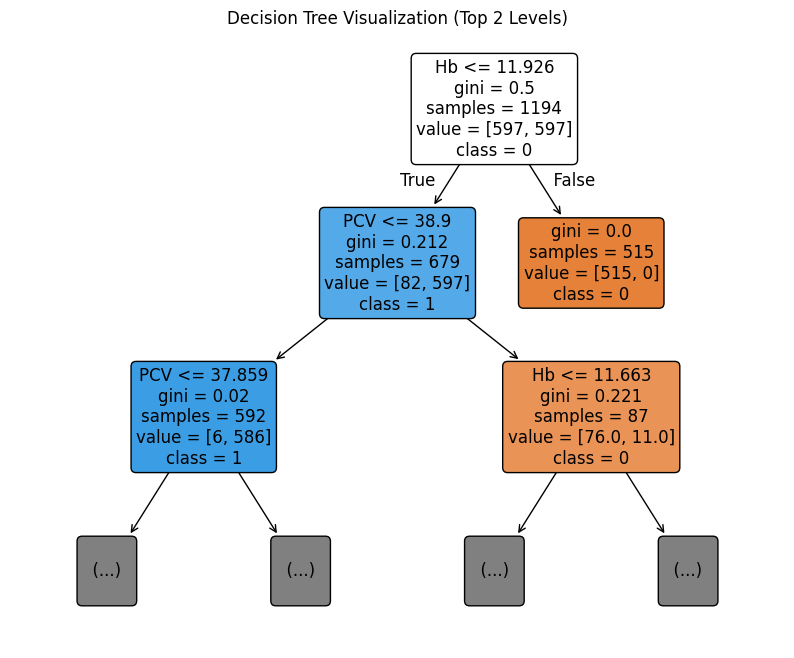

In [47]:
from sklearn.tree import plot_tree

# Assuming Decision Tree model is trained
dt_model = models["Decision Tree"]

# Plot the Decision Tree up to depth 2
plt.figure(figsize=(10,8))
plot_tree(
    dt_model,
    max_depth=2,  # Only top 2 levels
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Visualization (Top 2 Levels)")
plt.show()


In [48]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=77bb8f12b353e8346d64a19620fb2709b1cd23aea037429fa588d0e09ea031a0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime



Explaining test instance index 1 (True class: 0)
[('Hb > 12.34', -0.7079099634503617), ('33.50 < PCV <= 36.61', 0.03325911673782641)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


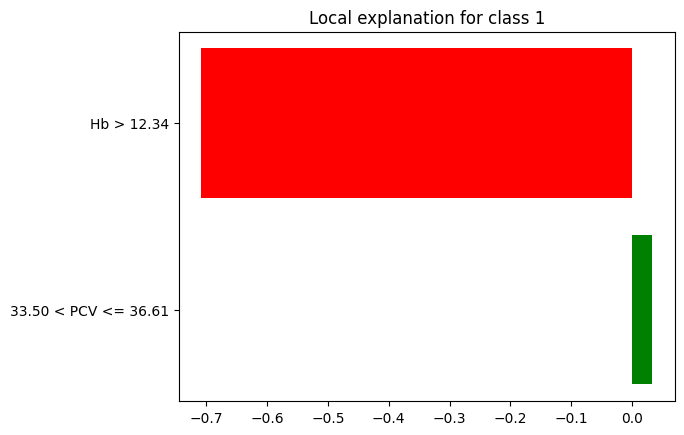


Explaining test instance index 0 (True class: 1)
[('Hb <= 11.00', 0.6286392733527667), ('PCV <= 31.10', 0.03310949205111046)]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


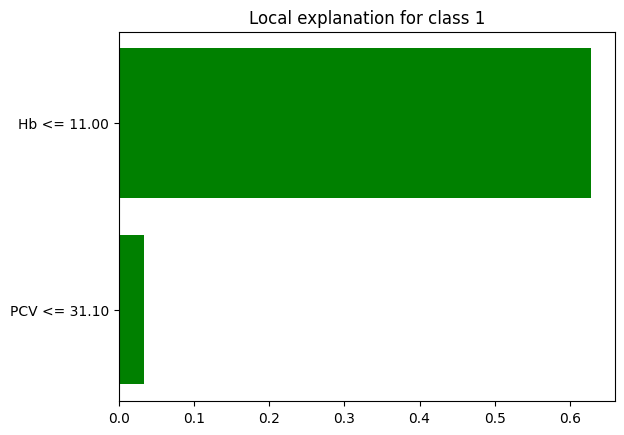

In [49]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

# Decision Tree model
dt_model = models["Decision Tree"]

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_model.classes_],
    mode='classification'
)

# Select a few test instances to explain
# Here we explain 2 instances: one from class 0, one from class 1
idx_class0 = np.where(y_test == 0)[0][0]
idx_class1 = np.where(y_test == 1)[0][0]

instances = [idx_class0, idx_class1]

for idx in instances:
    instance = X_test.iloc[idx].values
    print(f"\nExplaining test instance index {idx} (True class: {y_test.iloc[idx]})")

    # Generate LIME explanation
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=dt_model.predict_proba,
        num_features=len(X_train.columns)  # show all features
    )

    # Show explanation as list
    print(exp.as_list())

    # Plot explanation
    fig = exp.as_pyplot_figure()
    plt.show()


In [56]:
pip install SALib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 10.0 MB/s eta 0:00:00


      mu  mu_star  sigma  mu_star_conf
Hb  -1.5      1.5    0.0           0.0
PCV  0.0      0.0    0.0           0.0


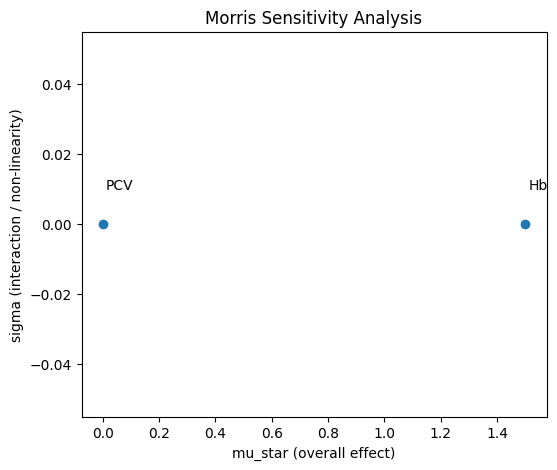

In [58]:
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
import pandas as pd
import matplotlib.pyplot as plt

problem = {
    'num_vars': X_test.shape[1],
    'names': X_test.columns.tolist(),
    'bounds': [[X_test[col].min(), X_test[col].max()] for col in X_test.columns],
    'num_levels': 4,
    'grid_jump': 1
}

param_values = morris_sample.sample(problem, N=1000, num_levels=4)
param_values_df = pd.DataFrame(param_values, columns=X_test.columns)

Y = dt_model.predict_proba(param_values_df)[:, 1]

Si = morris_analyze.analyze(problem, param_values, Y, conf_level=0.95, print_to_console=True)

plt.figure(figsize=(6,5))
plt.scatter(Si['mu_star'], Si['sigma'])
for i, name in enumerate(X_test.columns):
    plt.text(Si['mu_star'][i]+0.01, Si['sigma'][i]+0.01, name)
plt.xlabel('mu_star (overall effect)')
plt.ylabel('sigma (interaction / non-linearity)')
plt.title('Morris Sensitivity Analysis')
plt.show()


In [59]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

X = train_df_balanced.drop(columns=['Decision_Class'])
y = train_df_balanced['Decision_Class']

models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(criterion='gini', max_depth=None, n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(depth=7, iterations=200, learning_rate=0.1, random_state=42, verbose=0)
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n--- 5-Fold CV for {name} ---")
    fold_accuracies = []
    for fold, (train_index, val_index) in enumerate(kf.split(X, y), 1):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)
        acc = (y_pred_fold == y_val_fold).mean()
        fold_accuracies.append(acc)
        print(f"Fold {fold} Accuracy: {acc:.4f}")

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f"{name} Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")



--- 5-Fold CV for Decision Tree ---
Fold 1 Accuracy: 0.9958
Fold 2 Accuracy: 0.9791
Fold 3 Accuracy: 0.9833
Fold 4 Accuracy: 0.9874
Fold 5 Accuracy: 0.9916
Decision Tree Mean Accuracy: 0.9874 ± 0.0059

--- 5-Fold CV for Extra Trees ---
Fold 1 Accuracy: 0.9874
Fold 2 Accuracy: 0.9833
Fold 3 Accuracy: 0.9916
Fold 4 Accuracy: 0.9958
Fold 5 Accuracy: 0.9958
Extra Trees Mean Accuracy: 0.9908 ± 0.0049

--- 5-Fold CV for XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:19:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 Accuracy: 0.9833


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:19:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 Accuracy: 0.9791


...

Fold 3 Accuracy: 0.9833


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:19:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 Accuracy: 0.9874


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:19:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 Accuracy: 0.9832
XGBoost Mean Accuracy: 0.9832 ± 0.0026

--- 5-Fold CV for CatBoost ---
Fold 1 Accuracy: 0.9916
Fold 2 Accuracy: 0.9707
Fold 3 Accuracy: 0.9916
Fold 4 Accuracy: 0.9916
Fold 5 Accuracy: 0.9874
CatBoost Mean Accuracy: 0.9866 ± 0.0081
